# Market Analysis: Opportunities in Programming Education Markets

## Project Background and Goal

For this project, we assume the role of an analyst for an e-learning company offering courses on programming. This fictional company offers courses for web and mobile development, alongside other domains such as data science and game development. 

>The **end goal** is to promote the product/service. To do this, money will be invested into advertisements. A data-driven approach will be taken to identify target markets for these advertisements to improve the return on investment. 

### Plan of Attack

To achieve our goals, we could initially think about conducting surveys on markets we identify (e.g., survey the UK, US, Canadian *etc.* student bases to gauge interest). This can become **very costly**, so cheaper alternatives should be pursued first:

* One avenue is to *search existing data* that is likely to be relevant to our goals. One good candidate is a publically available [dataset](https://github.com/freeCodeCamp/2017-new-coder-survey) from [freeCodeCamp's 2017 New Coder Survey](https://www.freecodecamp.org/news/we-asked-20-000-people-who-they-are-and-how-theyre-learning-to-code-fff5d668969). 

* `freeCodeCamp` is a free e-learning platform offering courses on web development. Since they run a popular medium-sized publication (in excess of 400,000 followers), their survey attracted new coders with a variety of interests across many domains - ideal for our analysis.

#### We initially aim to answer the following questions:
>
>* What countries are new coders mainly located in?
>
>* What locations make up the largest proportion of new coders?
>
>* How much money are students from each location willing to spend to learn?

## Preparing the Workbook and Loading in the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
%matplotlib inline
pd.options.display.max_columns = 140 # set maximum number of columns that will be rendered to avoid truncated outputs

In [2]:
fCC = pd.read_csv('2017-fCC-New-Coders-Survey-Data.csv', low_memory=False) # low_memory=False to silence dtype warning

fCC.head()

,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,CodeEventFCC,CodeEventGameJam,CodeEventGirlDev,CodeEventHackathons,CodeEventMeetup,CodeEventNodeSchool,CodeEventNone,CodeEventOther,CodeEventRailsBridge,CodeEventRailsGirls,CodeEventStartUpWknd,CodeEventWkdBootcamps,CodeEventWomenCode,CodeEventWorkshops,CommuteTime,CountryCitizen,CountryLive,EmploymentField,EmploymentFieldOther,EmploymentStatus,EmploymentStatusOther,ExpectedEarning,FinanciallySupporting,FirstDevJob,Gender,GenderOther,HasChildren,HasDebt,HasFinancialDependents,HasHighSpdInternet,HasHomeMortgage,HasServedInMilitary,HasStudentDebt,HomeMortgageOwe,HoursLearning,ID.x,ID.y,Income,IsEthnicMinority,IsReceiveDisabilitiesBenefits,IsSoftwareDev,IsUnderEmployed,JobApplyWhen,JobInterestBackEnd,JobInterestDataEngr,JobInterestDataSci,JobInterestDevOps,JobInterestFrontEnd,JobInterestFullStack,JobInterestGameDev,JobInterestInfoSec,JobInterestMobile,JobInterestOther,JobInterestProjMngr,JobInterestQAEngr,JobInterestUX,JobPref,JobRelocateYesNo,JobRoleInterest,JobWherePref,LanguageAtHome,MaritalStatus,MoneyForLearning,MonthsProgramming,NetworkID,Part1EndTime,Part1StartTime,Part2EndTime,Part2StartTime,PodcastChangeLog,PodcastCodeNewbie,PodcastCodePen,PodcastDevTea,PodcastDotNET,PodcastGiantRobots,PodcastJSAir,PodcastJSJabber,PodcastNone,PodcastOther,PodcastProgThrowdown,PodcastRubyRogues,PodcastSEDaily,PodcastSERadio,PodcastShopTalk,PodcastTalkPython,PodcastTheWebAhead,ResourceCodecademy,ResourceCodeWars,ResourceCoursera,ResourceCSS,ResourceEdX,ResourceEgghead,ResourceFCC,ResourceHackerRank,ResourceKA,ResourceLynda,ResourceMDN,ResourceOdinProj,ResourceOther,ResourcePluralSight,ResourceSkillcrush,ResourceSO,ResourceTreehouse,ResourceUdacity,ResourceUdemy,ResourceW3S,SchoolDegree,SchoolMajor,StudentDebtOwe,YouTubeCodeCourse,YouTubeCodingTrain,YouTubeCodingTut360,YouTubeComputerphile,YouTubeDerekBanas,YouTubeDevTips,YouTubeEngineeredTruth,YouTubeFCC,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston
0,27.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15 to 29 minutes,Canada,Canada,software development and IT,NaN,Employed for wages,NaN,NaN,NaN,NaN,female,NaN,NaN,1.0,0.0,1.0,0.0,0.0,0.0,NaN,15.0,02d9465b21e8bd09374b0066fb2d5614,eb78c1c3ac6cd9052aec557065070fbf,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,start your own business,NaN,NaN,NaN,English,married or domestic partnership,150.0,6.0,6f1fbc6b2b,2017-03-09 00:36:22,2017-03-09 00:32:59,2017-03-09 00:59:46,2017-03-09 00:36:26,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,"some college credit, no degree",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34.0,0.0,NaN,NaN,NaN,NaN,NaN,"less than 100,000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,United States of America,NaN,NaN,Not working but looking for work,NaN,35000.0,NaN,NaN,male,NaN,NaN,1.0,0.0,1.0,0.0,0.0,1.0,NaN,10.0,5bfef9ecb211ec4f518cfc1d2a6f3e0c,21db37adb60cdcafadfa7dca1b13b6b1,NaN,0.0,0.0,0.0,NaN,Within 7 to 12 months,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,work for a nonprofit,1.0,Full-Stack Web Developer,in an office with other developers,English,"single, never married",80.0,6.0,f8f8be6910,2017-03-09 00:37:07,2017-03-09 00:33:26,2017-03-09 00:38:59,2017-03-09 00:37:10,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,1.0,"some college credit, no degree",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,NaN,

In [3]:
fCC.shape

(18175, 136)

In [4]:
fCC.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 18175 entries, 0 to 18174
Columns: 136 entries, Age to YouTubeTheNewBoston
dtypes: float64(105), str(31)
memory usage: 42.9 MB


The dataset contains responses from 18,175 participants with 136 response fields. The fields cover a broad range of topics. Some of the more important fields for our exploration/analysis include:

* Education Status 

* Job Role Interests 

* Amount of Money they are Willing to Spend to Learn Coding

* Country of Residence

## Verifying Sample Representativity

The population of interest for this report is all coders (likely new coders) that have an interest in the subjects/domains that our platform teaches:

**Primarily**

>* Web Development
>
>* Mobile Development

**With some cross-over into other domains:**

* Data Science

* Game Development

To ensure the fCC survey data is a representative sample for the population we are concerned with, we must ensure the sample contains the right categories of people for our purposes. We can verify this by checking the `JobRoleInterest` field - participants of the survey indicate specific job role(s) that they are aiming to become qualified for.

### Percentage Breakdown of Job Role Interest in the fCC Survey

In [5]:
job_role_interest = round(fCC["JobRoleInterest"].value_counts(normalize=True) * 100, 2)

job_role_interest.head(10) # the top 10 job role responses

JobRoleInterest
Full-Stack Web Developer                               11.77
  Front-End Web Developer                               6.44
  Data Scientist                                        2.17
Back-End Web Developer                                  2.03
  Mobile Developer                                      1.67
Game Developer                                          1.63
Information Security                                    1.32
Full-Stack Web Developer,   Front-End Web Developer     0.92
  Front-End Web Developer, Full-Stack Web Developer     0.80
  Product Manager                                       0.79
Name: proportion, dtype: float64

In [6]:
job_role_interest.tail(10) # the bottom 10 job role responses

JobRoleInterest
  Front-End Web Developer, Back-End Web Developer,   Mobile Developer, Full-Stack Web Developer, Data Engineer                                                                                                                                                                              0.01
  Product Manager, Full-Stack Web Developer,   Mobile Developer,   Front-End Web Developer, Data Engineer                                                                                                                                                                                   0.01
Information Security,   Data Scientist,   Mobile Developer                                                                                                                                                                                                                                  0.01
Game Developer,   Data Scientist, Full-Stack Web Developer,   Product Manager,   Mobile Developer,   Front-End Web De

The frequency table generated above provides a granular level of detail, but we can see from the top 10 survey responses that the subject matters we are aiming to provide a service for are indeed the main areas of interest for the participants of this survey.

* We can see web development makes up the largest proportion of learners, in-line with our services, with some interest spreading to mobile, game development and data science fields (which we can also accomodate on our platform).

* It is also interesting to see that some learners have indicated *multiple* areas of interest, spanning many job roles. 

Below, we will determine how many learners have a single job role interest versus those who have mixed interests.

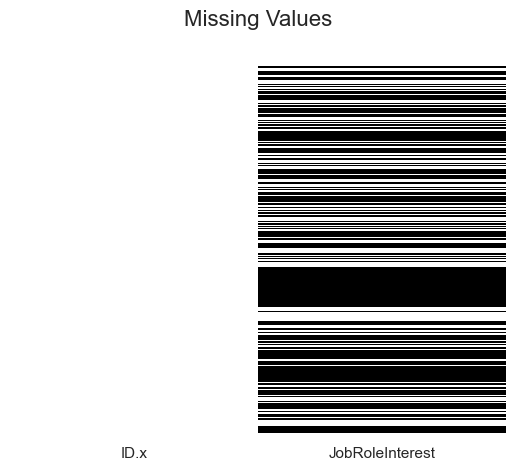

In [7]:
job_roles = fCC[["ID.x","JobRoleInterest"]]

sns.heatmap(job_roles.isnull(), yticklabels=False, cmap="gray_r", cbar=False)

plt.title("Missing Values", fontsize=16, y=1.08)

plt.show()

There are a number of null values present in the field (indicated by the black bars in the above heatmap).

In [8]:
no_null_job_roles = fCC["JobRoleInterest"].dropna() # job role interest column with null values removed

target_domains = no_null_job_roles.str.contains("Web Developer|Mobile Developer|Data Scientist|Game Developer", na=False) # boolean mask to filter job role interest column for target domains

target_domains.shape

(6992,)

After dropping all null values in the `JobRoleInterest` column, 6,992 records remain.

Below, we determine the frequency table for the number of job interests any participant put in their survey response.

In [9]:
splitted_no_null_job_roles = no_null_job_roles.str.split(",") # split job roles by comma to produce a list of all job roles for each participant

number_of_interests = splitted_no_null_job_roles.apply(lambda x: len(x)) # count number of job roles for each participant

abs_freq = number_of_interests.value_counts() # return absolute frequency for each number of job roles

percentage_freq = round(number_of_interests.value_counts(normalize=True) * 100, 2) # return the percentage frequency for each number of job roles

job_role_interest_table = pd.concat([abs_freq, percentage_freq], axis=1, sort=True) # combine absolute and percentage frequencies into a single, sorted table

job_role_interest_table.columns = ["Absolute Frequency", "Percentage Frequency"]

job_role_interest_table

,Absolute Frequency,Percentage Frequency
JobRoleInterest,,
1,2213,31.65
2,761,10.88
3,1111,15.89
4,1064,15.22
5,842,12.04
6,470,6.72
7,270,3.86
8,123,1.76
9,69,0.99


Of the ~7k remaining records, 31.65% (2,213 participants) indicated just one job role in the `JobRoleInterest` field. 

The remaining learners have mixed interests (2+ job role interests) - this is likely to be a positive for us, since our company can cater to multiple fields of interest rather than specialising on just one.

In [10]:
target_domain_percentage_table = round(target_domains.value_counts(normalize=True) * 100, 2)

target_domain_percentage_table

JobRoleInterest
True     93.32
False     6.68
Name: proportion, dtype: float64

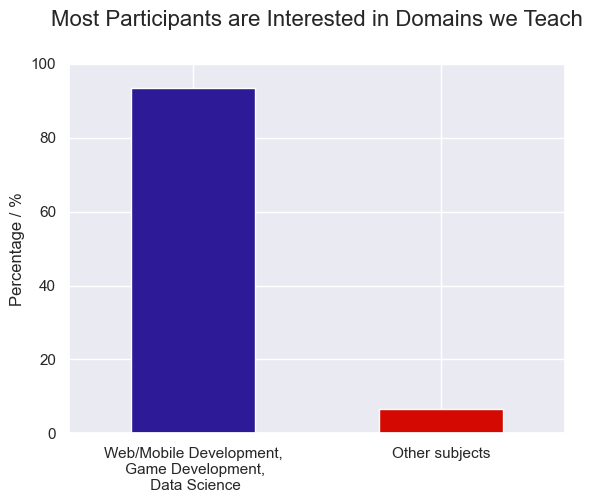

In [11]:
colors = ["#2D1A97", "#D30902"]

target_domain_percentage_table.plot.bar(color=colors, width=0.5)

plt.title("Most Participants are Interested in Domains we Teach", fontsize=16, y=1.08)

plt.xlabel("")
plt.xticks([0, 1], ["Web/Mobile Development,\n Game Development,\n Data Science", "Other subjects"], rotation=0)

plt.ylabel("Percentage / %", fontsize=12)
plt.ylim(0, 100)

plt.show()

### Remarks

It turns out over 93% of the participants of the fCC survey indicated a field of interest that is relevant to our service/product. Such figures provide a strong reason to consider this sample representative for our population of interest. 

We can now drill down further into the data, providing some indication of the kind of markets that may be best to invest advertising money into. As mentioned prior, some of the key questions to address include:

>* Where are new coders mainly located?
>
>* What locations have the **largest** densities of new coders?
>
>* How much money are students from each location willing to spend to learn?

## New Coder Locations

The dataset provides information on the location of participants at the country level in fields `CountryCitizen` (the participants country of origin) and `CountryLive` (the country where the participant currently lives).

The `CountryLive` variable is more relevant to our aims. Since the survey provides information at a country level, we can consider each country as a different market, framing our analysis to determine the best countries to advertise in.

A good starting point is to identify the number of potential customers in each country. Countries with larger volumes of potential customers will be more appropriate to invest into advertising campaigns.

Missing values are also present in the `CountryLive` field, which will need dropping before analysis.

In [12]:
fCC_sample = fCC[fCC["JobRoleInterest"].notnull()] # drop all null values from the JobRoleInterest column

In [13]:
fCC_sample.shape

(6992, 136)

We will use the above 6,992 records as the sample. These are new coders which have indicated a job role interest(s). 

We could have also restricted the sample further to include *only* responses that indicated an interest in the areas our company caters for, but for a more comprehensive overview of the overall market situation, we will leave in responses that cover other job roles (as this could provide important insights for our company to expand the services it provides).

### Handling Missing Values in the CountryLive Field

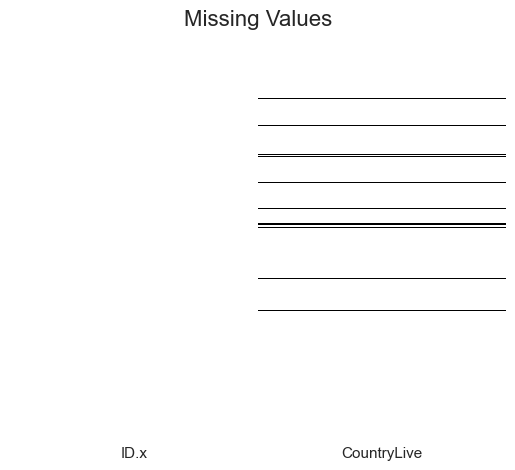

In [14]:
resident_countries = fCC_sample[["ID.x", "CountryLive"]]

sns.heatmap(resident_countries.isnull(), yticklabels=False, cmap="gray_r", cbar=False)

plt.title("Missing Values", fontsize=16, y=1.08)

plt.show()

There are a handful of null values in the sample which must be dropped.

In [15]:
no_null_countries = fCC_sample["CountryLive"].dropna() 

fCC_sample = fCC_sample[fCC_sample["CountryLive"].notnull()]

no_null_countries.shape

(6838,)

154 null values dropped.

In [16]:
abs_freq = no_null_countries.value_counts()

percentage_freq = round(no_null_countries.value_counts(normalize=True) * 100, 2)

resident_country_table = pd.concat([abs_freq, percentage_freq], axis=1)

resident_country_table.columns = ["AbsFreq", "PctFreq"]

resident_country_table.head(10) # top 10 countries of residence

,AbsFreq,PctFreq
CountryLive,,
United States of America,3125,45.70
India,528,7.72
United Kingdom,315,4.61
Canada,260,3.80
Poland,131,1.92
Brazil,129,1.89
Germany,125,1.83
Australia,112,1.64
Russia,102,1.49


The USA makes up the majority of the learner locations (at 45.7%) so this market seems to be a candidate for further investigation. India comes in second (at only 7.72%), with the UK and Canada close behind.

We will need to dig deeper to gain an insight into how much money learners from these markets are willing to spend on coding. There is little benefit from advertising in a densely packed market if the target audience are not willing to spend high volumes of money to learn.

## Willingness to Spend

The `MoneyForLearning` field describes the amount of money (in $USD) a participant has spent in total from the moment they began their coding journey to the moment they completed the survey. 

Our company offers subsriptions at **$59 per month**, so gaining an insight into monthly expenditure of learners from each market will be highly valuable information.

>To measure this, we can get an idea of the monthly spending habits of participants of the survey. We can derive a `MonthlySpend` column by taking the participant's budget for learning to code they provided in the `MoneyForLearning` field and divide this by the number of months the participant has been learning to code (from the `MonthsProgramming` field). 

This is, of course, a rough measure - the process and considerations will be elaborated on as the report continues.

---

From the information we have gleaned above, we can narrow down our investigation to the following markets:

>* USA
>
>* India
>
>* UK
>
>* Canada

These represent the greatest proportion of new coders and all have English as the country's official language - ideal for a company providing courses written in English.

In [17]:
fCC_sample[fCC_sample["MonthsProgramming"] == 0][["MonthsProgramming"]] 

,MonthsProgramming
234,0.0
616,0.0
653,0.0
906,0.0
1068,0.0
...,...
17965,0.0
18044,0.0
18055,0.0
18099,0.0


A number of students indicated they had spent 0 months programming (i.e., likely had just started to program that month). To avoid division by zero errors, we can replace any zeros with one.

In [18]:
fCC_sample["MonthsProgramming"] = fCC_sample["MonthsProgramming"].map(lambda x: x if x != 0 else 1) # replace 0 with 1

### Check for Missing Values

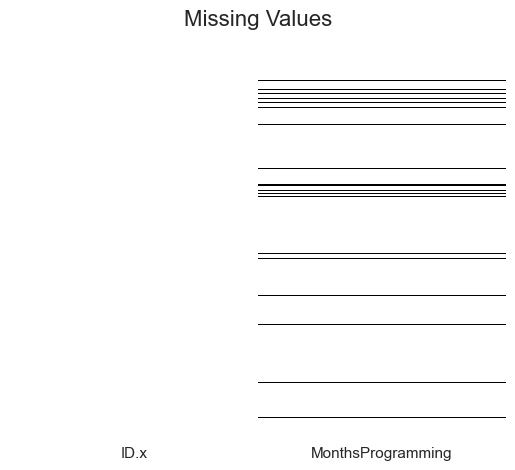

In [19]:
months_programming = fCC_sample[["ID.x","MonthsProgramming"]]

sns.heatmap(months_programming.isnull(), yticklabels=False, cmap="gray_r", cbar=False)

plt.title("Missing Values", fontsize=16, y=1.08)

plt.show()

In [20]:
fCC_sample = fCC_sample[fCC_sample["MonthsProgramming"].notnull()] # remove participants with null values in the MonthsProgramming column

In [21]:
# we derive a new column "MonthlySpend" which takes the total budget of a participant and divides by the number of months since starting their learning journey
fCC_sample["MonthlySpend"] = fCC_sample["MoneyForLearning"] / fCC_sample["MonthsProgramming"]

C:\Users\benke\AppData\Local\Temp\ipykernel_35972\1607020672.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fCC_sample["MonthlySpend"] = fCC_sample["MoneyForLearning"] / fCC_sample["MonthsProgramming"]


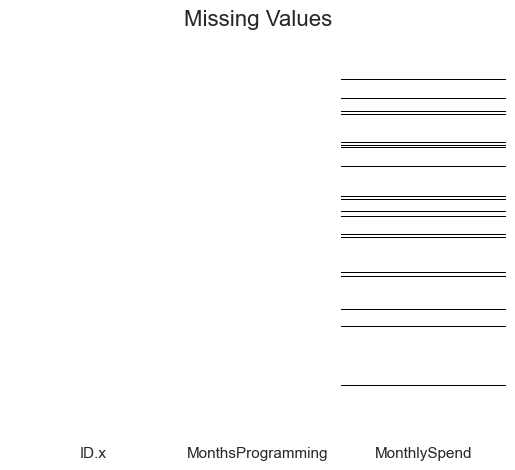

In [22]:
months_programming = fCC_sample[["ID.x", "MonthsProgramming", "MonthlySpend"]]

sns.heatmap(months_programming.isnull(), yticklabels=False, cmap="gray_r", cbar=False)

plt.title("Missing Values", fontsize=16, y=1.08)

plt.show()

The resulting null values in the new `MonthlySpend` column must be a result of null values in the `MoneyForLearning` field (since we have handled the missing values in the `MonthsProgramming` field).

We will drop the remaining null values (since we do not know the money spent by these learners).

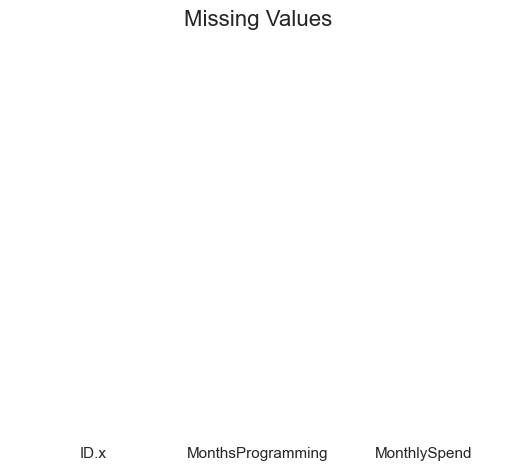

In [23]:
fCC_sample = fCC_sample[fCC_sample["MonthlySpend"].notnull()] # remove participants with null values in the MonthlySpend column

months_programming = fCC_sample[["ID.x", "MonthsProgramming", "MonthlySpend"]]

sns.heatmap(months_programming.isnull(), yticklabels=False, cmap="gray_r", cbar=False)

plt.title("Missing Values", fontsize=16, y=1.08)

plt.show()

No null values remain.

### Aggregating Monthly Spend by Country

In [24]:
monthly_spend_by_country = fCC_sample.pivot_table(index="CountryLive", values="MonthlySpend", aggfunc=["mean","median","min","max"])

monthly_spend_by_country.loc[["United States of America", "India", "Canada", "United Kingdom"],:]

,mean,median,min,max
,MonthlySpend,MonthlySpend,MonthlySpend,MonthlySpend
CountryLive,,,,
United States of America,227.997996,3.333333,0.0,80000.0
India,135.100982,0.000000,0.0,10000.0
Canada,113.510961,0.000000,0.0,5000.0
United Kingdom,45.534443,0.000000,0.0,1400.0


The mean of the monthly spend field indicates the USA has the greatest average monthly spend. Strangely, the mean monthly spend for India exceeds both Canada and the UK (we would expect India to be the smallest if we consider each country's GDP per capita).

We can see a significant influence of maximum extreme values - this is likely the main cause of the distorted mean values. A value of 80,000 significantly skews the USA's mean to the right for instance. 

The same can be said for the other countries too, although to a lesser extent. The maximum monthly spend values seem highly unrealisitic for the majority of users.

### Visualizing Outliers with Box Plots

A better sense of the distributions for each country is obtained by creating box plots. We can use this to identify outliers.

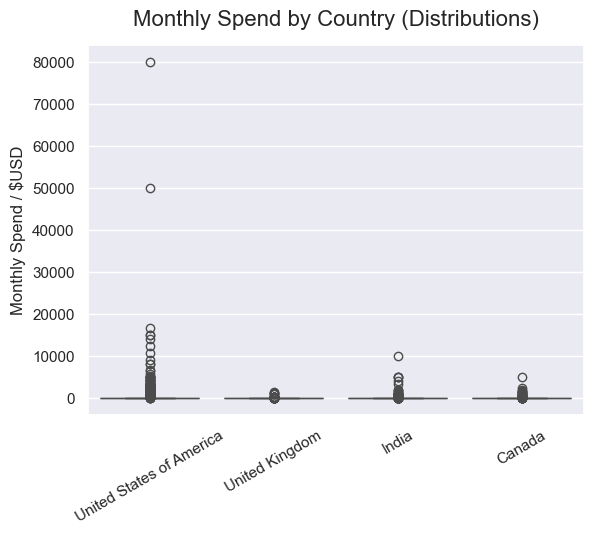

In [25]:
fCC_sample_top_4 = fCC_sample[fCC_sample["CountryLive"].isin(["United States of America", "India", "Canada", "United Kingdom"])]

sns.boxplot(x="CountryLive", y="MonthlySpend", hue="CountryLive", data=fCC_sample_top_4)

plt.title("Monthly Spend by Country (Distributions)", fontsize=16, y=1.03)

plt.xlabel("")
plt.xticks(rotation=30)

plt.ylabel("Monthly Spend / $USD")

plt.show()

We can see the influence of a number of outliers on the distributions. This is most apparent for the USA, with maximum values lying significantly above any of the outliers present across the other countries.

### Removal of Outliers

The values of 50k and 80k monthly spend is incredibly unrealistic, so we can remove these.

In [26]:
fCC_sample_top_4 = fCC_sample_top_4[fCC_sample_top_4["MonthlySpend"] < 20000] # remove the most extreme outliers (exceeding $20,000 per month)

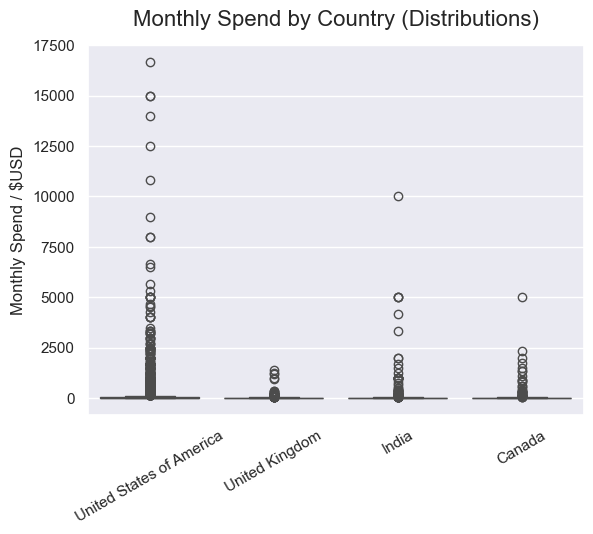

In [27]:
sns.boxplot(x="CountryLive", y="MonthlySpend", hue="CountryLive", data=fCC_sample_top_4)

plt.title("Monthly Spend by Country (Distributions)", fontsize=16, y=1.03)

plt.xlabel("")
plt.xticks(rotation=30)

plt.ylabel("Monthly Spend / $USD")

plt.show()

In [28]:
monthly_spend_by_country = fCC_sample_top_4.pivot_table(index="CountryLive", values="MonthlySpend", aggfunc=["mean","median","min","max"]) # pivot table for monthly spend by country

monthly_spend_by_country.loc[["United States of America", "India", "Canada", "United Kingdom"],:] # order by monthly spend column

,mean,median,min,max
,MonthlySpend,MonthlySpend,MonthlySpend,MonthlySpend
CountryLive,,,,
United States of America,183.800110,3.333333,0.0,16666.666667
India,135.100982,0.000000,0.0,10000.000000
Canada,113.510961,0.000000,0.0,5000.000000
United Kingdom,45.534443,0.000000,0.0,1400.000000


Removal of the two outliers above has caused a significant reduction in the mean monthly spend for the USA. 

There are still many other extreme values featured in the distributions - e.g., values above $6K USD in the US. These will need to be assessed to see if they can be rationalised. Why would these learners be spending such high volumes of cash? If we cannot reasonably explain this, the data is likely unreliable and probably resulted from an error in the data collection process (such as a participant typo or misunderstanding during the survey response).

### USA Extreme Values

In [29]:
fCC_sample_top_4[(fCC_sample_top_4["CountryLive"] == "United States of America") & (fCC_sample_top_4["MonthlySpend"] > 5000)][["MonthlySpend", "MonthsProgramming", "AttendedBootcamp", "BootcampFinish", "CodeEventConferences", "StudentDebtOwe"]]

,MonthlySpend,MonthsProgramming,AttendedBootcamp,BootcampFinish,CodeEventConferences,StudentDebtOwe
718,8000.000000,1.0,1.0,0.0,1.0,NaN
1222,6500.000000,2.0,1.0,0.0,NaN,NaN
3145,5666.666667,3.0,1.0,0.0,NaN,NaN
3184,9000.000000,1.0,1.0,1.0,NaN,NaN
3930,10833.333333,6.0,0.0,NaN,NaN,40000.0
6805,15000.000000,1.0,1.0,1.0,NaN,45000.0
7198,14000.000000,5.0,0.0,NaN,1.0,NaN
7505,6666.666667,3.0,1.0,0.0,NaN,20000.0
9778,8000.000000,1.0,1.0,0.0,NaN,45000.0
13145,5333.333333,3.0,1.0,0.0,1.0,NaN


#### Remarks

Above, we retrieve some fields of participants living in the USA with a monthly spend value exceeding $5,000. Eight participants out of the 13 listed attend/attended a bootcamp during their journey, which may contribute to the elevated costs for some of these participants. Three of the participants also attended a conference/conferences, which is also likely to contribute to additional expense.

Some of the participants indicated they have a student debt to pay off. The participant ID `16997` has a monthly spend value that is **identical** to their student debt - this user may have misunderstood the original survey question and answered with the outstanding cost of a degree they took previously.

>Another additional point of consideration - if the user has only been learning to program for a short period of time, their monthly spend value will be **significantly greater** since this is calculated by dividing the total budget of the learner by the months spent learning.

>It is highly likely in the majority of cases, most learners who are spending a large sum of money are attending a bootcamp. These learners often pay in-full upfront for a 6-Month/9-Month/12-Month course, so their spending after the first month will fall to **zero**.

It is reasonable to remove outliers according to the following criteria:

* If the participant is not attending/did not attend a bootcamp - it seems highly unrealistic to spend this much without paying for a professionally tailored bootcamp style course.

* If the participant had been programming for 3 months or less at the time of survey completion.


In [30]:
no_bootcamp = fCC_sample_top_4[(fCC_sample_top_4["AttendedBootcamp"] == 0) & (fCC_sample_top_4["CountryLive"] == "United States of America") & (fCC_sample_top_4["MonthlySpend"] > 5000)]

fCC_sample_top_4 = fCC_sample_top_4.drop(no_bootcamp.index) # drop USA participants with monthly spends exceeding $5000 who did not attend a bootcamp

In [31]:
three_months_or_less = fCC_sample_top_4[(fCC_sample_top_4["MonthsProgramming"] <= 3) & (fCC_sample_top_4["CountryLive"] == "United States of America") & (fCC_sample_top_4["MonthlySpend"] > 5000)]

fCC_sample_top_4 = fCC_sample_top_4.drop(three_months_or_less.index) # drop USA participants with monthly spends exceeding $5000 who have been coding for 3 months or less at the time of survey completion

### Revisualizing the Distribution After USA Outliers Removed

In [32]:
fCC_sample_top_4[(fCC_sample_top_4["CountryLive"] == "United States of America") & (fCC_sample_top_4["MonthlySpend"] > 5000)][["MonthlySpend", "MonthsProgramming", "AttendedBootcamp", "BootcampFinish", "CodeEventConferences", "StudentDebtOwe"]]

,MonthlySpend,MonthsProgramming,AttendedBootcamp,BootcampFinish,CodeEventConferences,StudentDebtOwe


All of the extreme values identified were removed according to the criteria outlined.

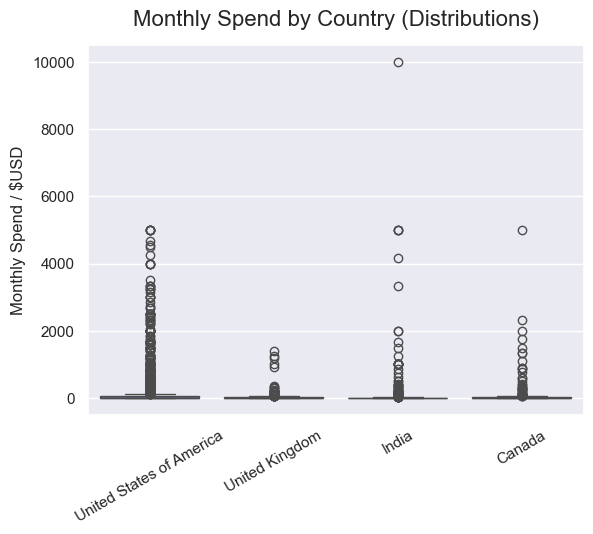

In [33]:
sns.boxplot(x="CountryLive", y="MonthlySpend", hue="CountryLive", data=fCC_sample_top_4)

plt.title("Monthly Spend by Country (Distributions)", fontsize=16, y=1.03)

plt.xlabel("")
plt.xticks(rotation=30)

plt.ylabel("Monthly Spend / $USD")

plt.show()

### India and Canada Outliers

A similar process of assessing the reliability of the extreme values can be performed with responses from participants living in India and Canada.

In [34]:
india_outliers = fCC_sample_top_4[(fCC_sample_top_4["CountryLive"] == "India") & (fCC_sample_top_4["MonthlySpend"] > 2500)][["MonthlySpend", "MonthsProgramming", "AttendedBootcamp", "BootcampFinish", "CodeEventConferences", "StudentDebtOwe"]]

india_outliers

,MonthlySpend,MonthsProgramming,AttendedBootcamp,BootcampFinish,CodeEventConferences,StudentDebtOwe
1728,5000.000000,4.0,0.0,NaN,NaN,NaN
1755,3333.333333,15.0,0.0,NaN,NaN,NaN
7989,5000.000000,1.0,0.0,NaN,1.0,2500.0
8126,5000.000000,1.0,0.0,NaN,NaN,10000.0
13398,10000.000000,2.0,0.0,NaN,NaN,NaN
15587,4166.666667,24.0,0.0,NaN,NaN,25000.0


From the responses of the participants living in India with monthly spends exceeding $2,500, **none of them attended a bootcamp**. It is very difficult to know how reliable these data are since these expenses seem far too high for learners who did not attend any form of paid bootcamp.

The full survey question was: *"Aside from university tuition, how much have you spent so far learning to code (in US dollars)?"*. It could be possible that some individuals misunderstood the question and included some of their university expenses in their final answer.

Since we cannot confidently rationalise these high monthly spend values, it seems most appropriate to drops these records.

In [35]:
fCC_sample_top_4 = fCC_sample_top_4.drop(india_outliers.index) # drop India participants with monthly spends exceeding $2500

In [36]:
canada_outliers = fCC_sample_top_4[(fCC_sample_top_4["CountryLive"] == "Canada") & (fCC_sample_top_4["MonthlySpend"] > 3000)][["MonthlySpend", "MonthsProgramming", "AttendedBootcamp", "BootcampFinish", "CodeEventConferences", "StudentDebtOwe"]]

The situation for the canada extreme value resembles the USA case. The participant attended a bootcamp, likely explaining the expense. The size of the monthly spend is likely to be highly inflated since this participant probably enrolled in a bootcamp 2 months prior, paying $10,000 upfront for a longer term course. These expenses will drop if the total was paid in the first month, so we can follow the previous criteria and remove this unreliable monthly spend value.

In [37]:
fCC_sample_top_4 = fCC_sample_top_4.drop(canada_outliers.index) # drop Canada participants with monthly spends exceeding $3000

### Revisualizing After Outlier Handling

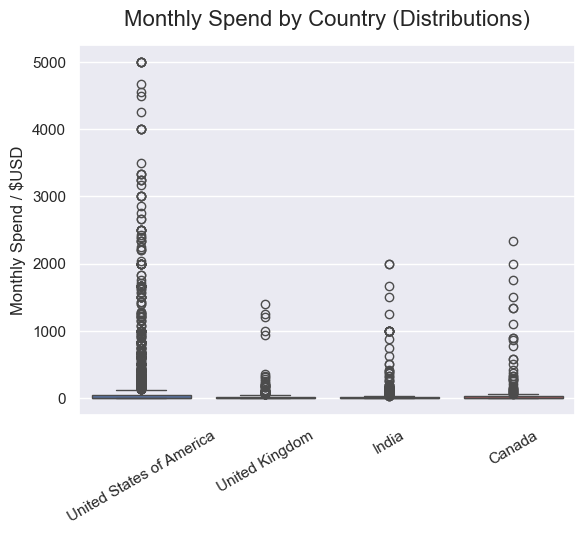

In [38]:
sns.boxplot(x="CountryLive", y="MonthlySpend", hue="CountryLive", data=fCC_sample_top_4)

plt.title("Monthly Spend by Country (Distributions)", fontsize=16, y=1.03)

plt.xlabel("")
plt.xticks(rotation=30)

plt.ylabel("Monthly Spend / $USD")

plt.show()

A further look into some of the extremes may still be necessary in some cases, but the worst offending extremes have been eliminated in an effort to make the mean a more representative measure of central tendency for each distribution. 

>This is essential - we are utilising insights provided by the mean of each distribution to assess which country is likely to provide customers who are most willing to spend $59 per month on a subscription for our e-learning platform.

### Recomputing the Aggregated Metrics by Country After Some Outlier Handling

In [39]:
monthly_spend_by_country = fCC_sample_top_4.pivot_table(index="CountryLive", values="MonthlySpend", sort=True) # pivot table for monthly spend by country. default aggfunc is mean

monthly_spend_by_country.index.name = "Country" # rename the index label to Country

top_4_resident_country_table = resident_country_table.loc[["United States of America", "Canada", "India", "United Kingdom"],:] # select top 4 countries by number of new coders

top_4_resident_country_table.index.name = "Country" # rename the index label to Country

combined_aggregated_data = pd.merge(left=monthly_spend_by_country, right=top_4_resident_country_table, how="left", on="Country") # merge monthly spend by country with top 4 countries by number of new coders

combined_aggregated_data.index = combined_aggregated_data.index.map({"United States of America": "USA", "Canada": "Canada", "India": "India", "United Kingdom": "UK"}) # rename the indexes

combined_aggregated_data.loc[["USA", "Canada", "India", "UK"],:] # order by monthly spend

,MonthlySpend,AbsFreq,PctFreq
Country,,,
USA,138.982678,3125,45.70
Canada,93.065400,260,3.80
India,65.758763,528,7.72
UK,45.534443,315,4.61


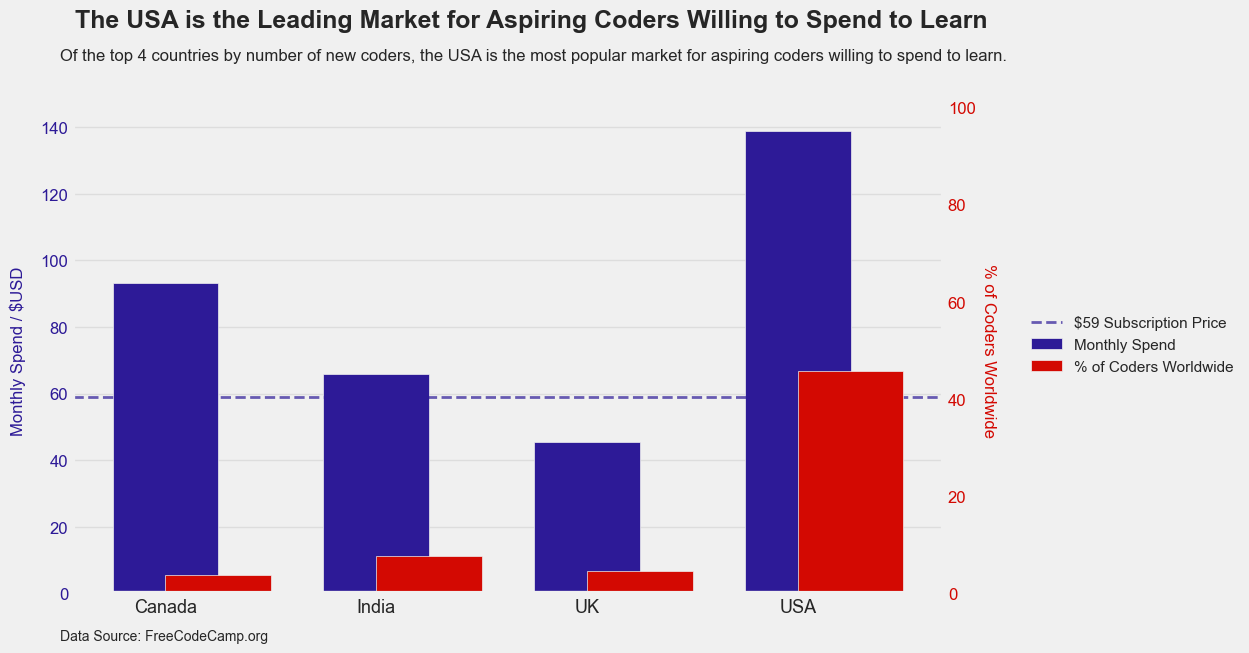

In [40]:
colors = ["#2D1A97", "#D30902"]

plt.style.use("fivethirtyeight")

fig, ax1 = plt.subplots(figsize=(10, 6))

# plot monthly spend
ax1.bar(x=combined_aggregated_data.index, height=combined_aggregated_data["MonthlySpend"], color=colors[0], width=0.5, align="center", label="Monthly Spend")
ax1.set_ylabel("Monthly Spend / $USD", color=colors[0], labelpad=10, size=12) # format y-axis label
ax1.tick_params(axis='y', labelcolor=colors[0], width=0, labelsize=12) # format y-axis tick labels
ax1.tick_params(axis='x', labelsize=13) # format x-axis tick labels

ax1.axhline(59, color="#2D1A97", linestyle="dashed", linewidth=2, label="$59 Subscription Price", alpha=0.7) # add a horizontal line at $59

ax1.grid(axis='x', alpha=0) # hide vertical gridlines
ax1.grid(axis='y', alpha=0.5) # soften horizontal gridlines

# create a second axis on the right
ax2 = ax1.twinx()

# plot percentage frequency on second axis
ax2.bar(x=combined_aggregated_data.index, height=combined_aggregated_data["PctFreq"], color=colors[1], width=0.5, align="edge", label="% of Coders Worldwide")
ax2.set_ylabel("% of Coders Worldwide", color=colors[1], labelpad=15, size=12, rotation=270) # format second y-axis label
ax2.tick_params(axis='y', labelcolor=colors[1], width=0, grid_linewidth=0, labelsize=12) # format second y-axis tick labels
ax2.set_ylim(0, 100) # set second y-axis limits

ax1.text(-0.43, 170, s="The USA is the Leading Market for Aspiring Coders Willing to Spend to Learn", fontsize=18, ha="left", weight="bold") # add title
ax1.text(-0.5, 160, s="Of the top 4 countries by number of new coders, the USA is the most popular market for aspiring coders willing to spend to learn.", fontsize=12, ha="left") # add subtitle
ax1.text(-0.5, -14, s="Data Source: FreeCodeCamp.org", fontsize=10) # add data source

plt.xlabel("")
plt.xticks(combined_aggregated_data.index, rotation=0)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, bbox_to_anchor=(1.35, 0.6), facecolor="none", edgecolor="none") # place legend to the right of the plot and remove bounding box

plt.show()

### Remarks

*Note, we are making these observations from the fCC survey results - a sample. We have demonstrated that the sample is appropriately representative for the population we are attempting to describe (the global population of new coders with interests relevant to services we provide).*

>* According to the aggregated data, the USA is likely to have the greatest number of learners who would be willing to spend $59 per month (since the mean monthly spend is almost $139). This observation, paired with the fact that USA residents also made up **over 45%** of the survey responses makes this a clear candidate for the top market to invest advertising into. 
>
>* Of the four regions with the greatest number of new coders, the United Kingdom has the lowest mean monthly spend (at around $45 per month). This suggests a typical new coder who is a resident of the UK would not be willing to purchase a $59 subscription for our service, so on this basis, the UK would not be an ideal choice.

The second best market is less clear cut. Arguments could be made for either Canada or India:

>* The mean monthly spend is clearly greater for Canadian residents (at ~$93 per month compared to India's ~$65 per month), however, India makes up a greater proportion of new coders (at 7.7%) whilst the Canadian market only contributes 3.8% to the total number of new coders.

If we value the market with the greater volume of potential customers, India would be a sensible choice. If we are looking to potentially raise prices for our services in the future as we develop our platform, it may be wiser to invest in advertisements in Canada where the mean monthly spend is notably larger.

---

At this stage, there are a number of options to consider:

* Allocate the entire advertising budget to the USA market

* Advertise in the USA, Canada and India (with an appropriate split *e.g.,* 60% USA, 25% India, 15% Canada)

* Advertise in the USA and *only* Canada or India (again, with an appropriate split *e.g.,* 70% USA, 30% Second Choice)

It may be wisest to send this to the marketing department for their domain-specific knowledge. They may require additional surveys on the Canadian and Indian markets to come to the best conclusion.


## Conclusions

Market analysis has been conducted to provide insights into the best markets to pursue for a marketing campaign related to a coding/web development e-learning platform. 

Knowledge related to new coder locations and spending behaviour has been acquired, leading to the following conclusions:

>* Using the fCC survey sample as a representative of the wider global coder population, it is likely that the **USA** has a significant number of new coders who fit the target audience for the service we provide as a company. The fact that many learners are likely to be willing to pay a monthly bill of $59 in the pursuit of learning to code makes this a **clear-cut winner**.
>
>* A **sensible secondary market** to consider investing in would be **India or Canada**. Further surveys on these specific markets could be pursued to cement a final decision or the decision can be forwarded to the marketing department as they may be better equipped to provide an answer due to their domain specific knowlegde.
>
>* The **UK as a market for new coders is less desirable** for our company due to the lower mean monthly spending metric of ~$45 per month. This does not meet the current $59 per month price point our company serves.